# Import Libraries

install libraries using !pip install 
1. nltk
2. tqdm
Note: code is taking time to preprocess so please check [*], if code block is running, particularly SVM is taking time in processing.
    If libraries is not installed properly, it will still throw error.
    We have use 50 D glove vectors file which is also attached with train.csv while uploading code on course link.

In [1]:
import numpy as np
import pandas as pd
import nltk
from sklearn import preprocessing,metrics 
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [2]:
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Read data, fillna(' ')` is used to fill any missing values in the DataFrame with a single space.
data = pd.read_csv('train.csv').fillna(' ')

# This line fills any missing values specifically in the 'comment_text' column with the string "missing". It modifies the DataFrame in-place
data['comment_text'].fillna("missing", inplace=True)

#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(data["comment_text"],data[classes],test_size=0.25,random_state=55)
data_text = pd.concat([X_train,X_test])

In [3]:
X_train

110693    "\nYewhock, perhaps you should read What vanda...
48103     I personally feel that the links should remain...
67060     I will point out one last thing. Ever new meta...
141841    renault \n\nyou sad little bpy for driving a r...
92780     Ars Technica \n\nWell, I figured there was no ...
                                ...                        
129565    "\n\nThat's fine, but as I stated, they aren't...
147325    i love you \n\nu are my boo. I love you so muc...
82888     stop! \n\nplease stop deleting my stuff, and g...
4762      "\n\n?? Most anarchists recognize the existenc...
127437    "==M. Antoine==\n\nA proposed deletion templat...
Name: comment_text, Length: 119678, dtype: object

In [4]:
y_train

,toxic,severe_toxic,obscene,threat,insult,identity_hate
110693,0,0,0,0,0,0
48103,0,0,0,0,0,0
67060,0,0,0,0,0,0
141841,1,0,1,0,0,0
92780,0,0,0,0,0,0
...,...,...,...,...,...,...
129565,0,0,0,0,0,0
147325,0,0,0,0,0,0
82888,0,0,0,0,0,0
4762,0,0,0,0,0,0


In [5]:
#glove embedding
GLOVE_6B_50D_PATH = "glove.6B.50d.txt"
glove = {}
glove_path = open(GLOVE_6B_50D_PATH)
for line in tqdm(glove_path):
    line_arr = line.split()
    word = line_arr[0]
    glove[word] = np.asarray(line_arr[1:], dtype='float32')
glove_path.close()

400000it [00:03, 127424.81it/s]


In [8]:
#normalization 
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

porter = PorterStemmer()
sw = set(stopwords.words('english'))
sw.update(['.', "'", '(', ')', '[', ']', '{', '}', ',', '"', ':', ';'])

def vectorize(sentence):
    words = str(sentence).lower()  
    tokenized = word_tokenize(words)
    updated_tokens = []
    final_tokens = []
    
    for word in tokenized:
        if not word in sw and word.isalpha(): 
            updated_tokens.append(word)
            
    for token in updated_tokens:
        try:
            final_tokens.append(glove[token.lower()])  
        except:
            continue  
    
    final_tokens = np.array(final_tokens)
    total =  final_tokens.sum(axis=0)
    data_type = type(total)
    
    if data_type != np.ndarray: 
        return np.zeros(50)  
    
    denom = np.sqrt((total ** 2).sum())
    return total / denom

[nltk_data] Downloading package punkt to /Users/s1mankhan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [9]:
xg_train = [vectorize(sentence) for sentence in tqdm(X_train)]
xg_test = [vectorize(sentence) for sentence in tqdm(X_test)]

100%|███████████████████████████████████| 39893/39893 [00:13<00:00, 2929.06it/s]


In [10]:
xg_train

[array([ 0.0592724 , -0.00091907, -0.05301768, -0.07887779,  0.11906683,
         0.07080283, -0.03586026, -0.05089955, -0.0513643 ,  0.08541743,
        -0.07365511,  0.05065371, -0.04861155, -0.03916892,  0.20218453,
         0.05177532,  0.02697775,  0.0231556 ,  0.05652422, -0.13873541,
         0.04806439,  0.10631402,  0.0896881 ,  0.05654962,  0.16287823,
        -0.37563744, -0.09648248,  0.0790463 ,  0.20951025, -0.13228008,
         0.7162055 ,  0.01861079, -0.04007455, -0.20369962, -0.07945947,
         0.02653433,  0.02036536, -0.02475045, -0.04165443, -0.02010745,
        -0.044695  , -0.02130884,  0.00652707,  0.15210822,  0.0864099 ,
        -0.04109924, -0.01410868,  0.01886329,  0.0345928 ,  0.05236042],
       dtype=float32),
 array([ 0.0770053 ,  0.0119742 ,  0.13930716,  0.04154592,  0.09011206,
        -0.04095172, -0.09903023,  0.00473194, -0.02890938, -0.02197114,
        -0.06514604,  0.06423777, -0.06836249,  0.02848162,  0.159178  ,
         0.01407708, -0.069

In [11]:
xg_test

[array([ 0.09836539, -0.03130533, -0.11070399, -0.25227726,  0.18904948,
        -0.01682528,  0.1403725 ,  0.10102426, -0.0015678 ,  0.12594886,
        -0.03077312,  0.11776046, -0.00086027, -0.12589355,  0.14698063,
         0.0158413 ,  0.07518966, -0.01191853,  0.01892439, -0.02301159,
        -0.08065894,  0.1012366 ,  0.06495099,  0.02507224,  0.23524217,
        -0.36764297, -0.19520147, -0.02806396,  0.19645934, -0.08806019,
         0.56093955,  0.16408972, -0.06243452, -0.08095776, -0.149835  ,
         0.0067535 ,  0.05704894, -0.16031581, -0.06480242,  0.04004084,
        -0.05413083, -0.06038122, -0.03140983,  0.19949557, -0.00777647,
         0.04831713, -0.09629645,  0.02415907, -0.02733666, -0.07385675],
       dtype=float32),
 array([ 0.05003782,  0.09967699,  0.0370344 , -0.05839681,  0.07537074,
        -0.04032645, -0.15399367, -0.03709773, -0.0251938 ,  0.00980465,
        -0.07194752,  0.08640739, -0.00933121,  0.0165251 ,  0.16016564,
         0.01159107, -0.016

# Support Vector Machine

In [12]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from tqdm import tqdm

# Define a smaller sample size.
#Sampling
sample_size = 20000  # Adjust as needed

# Create a subset of the data
xg_train_sample = xg_train[:sample_size]
y_train_sample = y_train[:sample_size]
xg_test_sample = xg_test[:sample_size]
y_test_sample = y_test[:sample_size]

# Define the SVM model with parallel processing and caching
svm_model = OneVsRestClassifier(SVC(kernel='rbf', probability=True))

# Fit the model
svm_model.fit(xg_train_sample, y_train_sample)

# Get probabilities using decision function
y_pred_decision = svm_model.decision_function(xg_test_sample)

# Threshold the probabilities
y_pred_thresholded = (y_pred_decision > 0).astype(int)

# Test Accuracy 

To extract values of y-test samples

In [13]:
y_test_sample = y_test_sample.values

In [14]:
# Calculate accuracy on the full test data
accuracy = accuracy_score(y_test_sample, (y_pred_thresholded > 0.5))
print("Test Accuracy: %.2f%%" % (accuracy * 100))

Test Accuracy: 90.67%


# F1 Score

In [15]:
from sklearn.metrics import f1_score
from sklearn.preprocessing import MultiLabelBinarizer

# Binarize y_pred
threshold = 0.5
y_pred_binarized = (y_pred_thresholded > threshold).astype(int)

# Flatten the arrays
y_test_flat = y_test_sample.flatten()
y_pred_flat = y_pred_binarized.flatten()

# Calculate F1-score
f1 = f1_score(y_test_flat, y_pred_flat, average='macro')

print("F1-score:", f1)

F1-score: 0.7297642538765446


# Probability Callibration curve

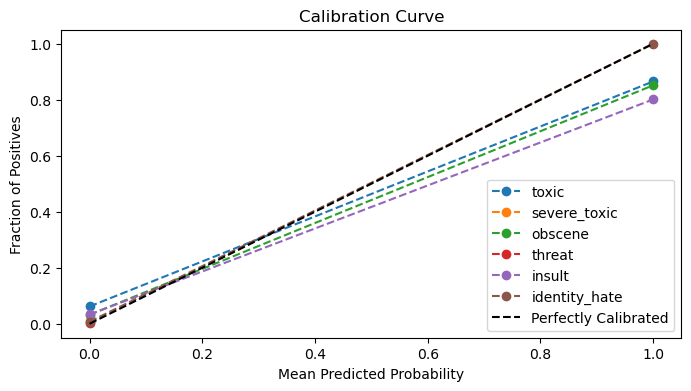

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
from sklearn.utils.multiclass import unique_labels

def plot_calibration_curve(y_test_sample, y_pred_thresholded, class_names=None, n_bins=10, strategy='uniform'):
    # Get unique classes from y_test_sample
    classes = unique_labels(y_test_sample)
    
    # Binarize the labels
    y_test_bin = label_binarize(y_test_sample, classes=classes)
    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(8, 4))

    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], y_pred_thresholded[:, i], n_bins=n_bins, strategy=strategy)
        label = f'Class {classes[i]}' if class_names is None else class_names[i]
        plt.plot(prob_pred, prob_true, marker='o', label=label, linestyle='--')

    plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title('Calibration Curve')
    plt.legend(loc='lower right')
    plt.show()

# Class names corresponding to the classes in y_test_sample
class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Specify the number of bins
n_bins = 10

plot_calibration_curve(y_test_sample, y_pred_thresholded, class_names=class_names, n_bins=n_bins)


# Confusion Matrix

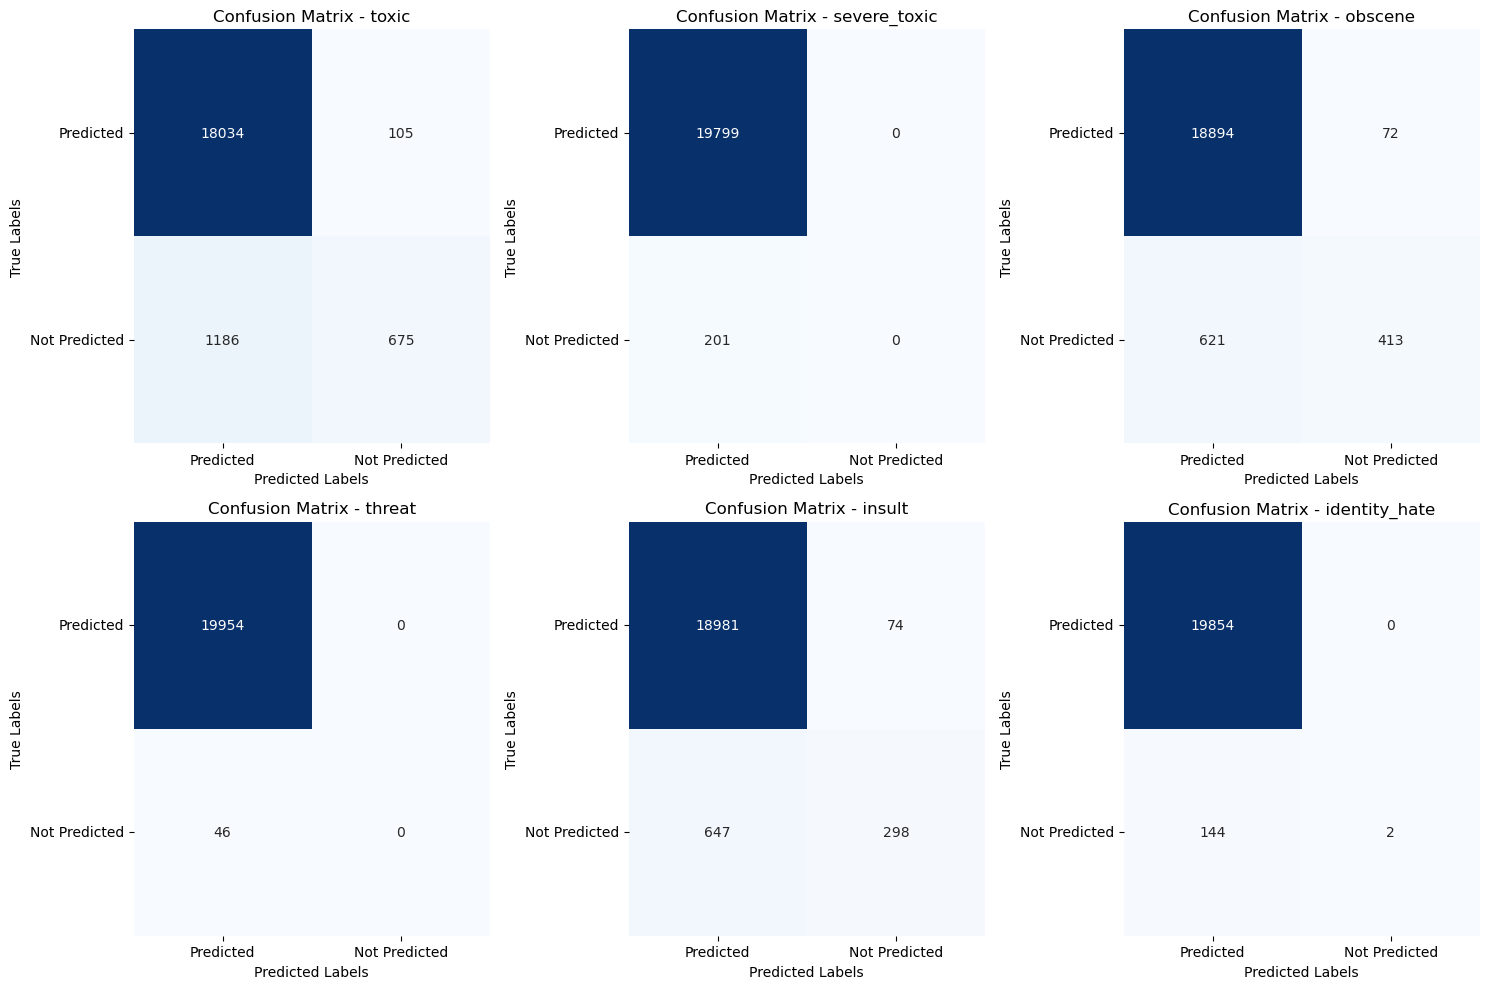

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns

# Define class names
class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

y_pred_binary = (y_pred_thresholded > 0.5).astype(int)

# Compute the confusion matrix for each label
cm = multilabel_confusion_matrix(y_test_sample, y_pred_binary)

# Plot confusion matrices for each label
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flatten()):
    sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted', 'Not Predicted'], yticklabels=['Predicted', 'Not Predicted'],
                ax=ax)
    ax.set_title(f'Confusion Matrix - {class_names[i]}')
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
    ax.xaxis.set_tick_params(rotation=0)
    ax.yaxis.set_tick_params(rotation=0)
plt.tight_layout()
plt.show()

# Logistic Regression

In [18]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#Sampling
# Define a smaller sample size
sample_size = 20000  # Adjust as needed

# Create a subset of the data
xg_train_sample = xg_train[:sample_size]
y_train_sample = y_train[:sample_size]
xg_test_sample = xg_test[:sample_size]
y_test_sample = y_test[:sample_size]

# Logistic Regression with OneVsRestClassifier
logreg = OneVsRestClassifier(LogisticRegression())

# Fit the model on the selected training data
logreg.fit(xg_train_sample, y_train_sample)

# Predict probabilities for the full test data
y_pred_logreg = logreg.predict_proba(xg_test_sample)

# Test Accuracy

In [19]:
# Calculate accuracy on the full test data
accuracy = accuracy_score(y_test_sample, (y_pred_logreg > 0.5))
print("Test Accuracy: %.2f%%" % (accuracy * 100))

Test Accuracy: 90.48%


# F1 score

In [20]:
from sklearn.metrics import f1_score
from sklearn.preprocessing import MultiLabelBinarizer

y_test_sample = y_test_sample.values

# Binarize y_pred
threshold = 0.5
y_pred_binarized = (y_pred_logreg > threshold).astype(int)

# Flatten the arrays
y_test_flat = y_test_sample.flatten()
y_pred_flat = y_pred_binarized.flatten()

# Calculate F1-score
f1 = f1_score(y_test_flat, y_pred_flat, average='macro')

print("F1-score:", f1)

F1-score: 0.7376123843699134


# Probability callibration curve

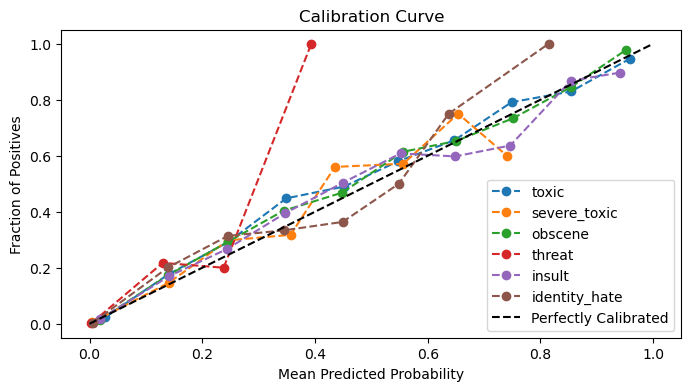

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
from sklearn.utils.multiclass import unique_labels

def plot_calibration_curve(y_test_sample, y_pred_logreg, class_names=None, n_bins=10, strategy='uniform'):
    # Get unique classes from y_test_sample
    classes = unique_labels(y_test_sample)
    
    # Binarize the labels
    y_test_bin = label_binarize(y_test_sample, classes=classes)
    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(8, 4))

    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], y_pred_logreg[:, i], n_bins=n_bins, strategy=strategy)
        label = f'Class {classes[i]}' if class_names is None else class_names[i]
        plt.plot(prob_pred, prob_true, marker='o', label=label, linestyle='--')

    plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title('Calibration Curve')
    plt.legend(loc='lower right')
    plt.show()

# Class names corresponding to the classes in y_test_sample
class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Specify the number of bins
n_bins = 10

plot_calibration_curve(y_test_sample, y_pred_logreg, class_names=class_names, n_bins=n_bins)


# Confusion Matrix

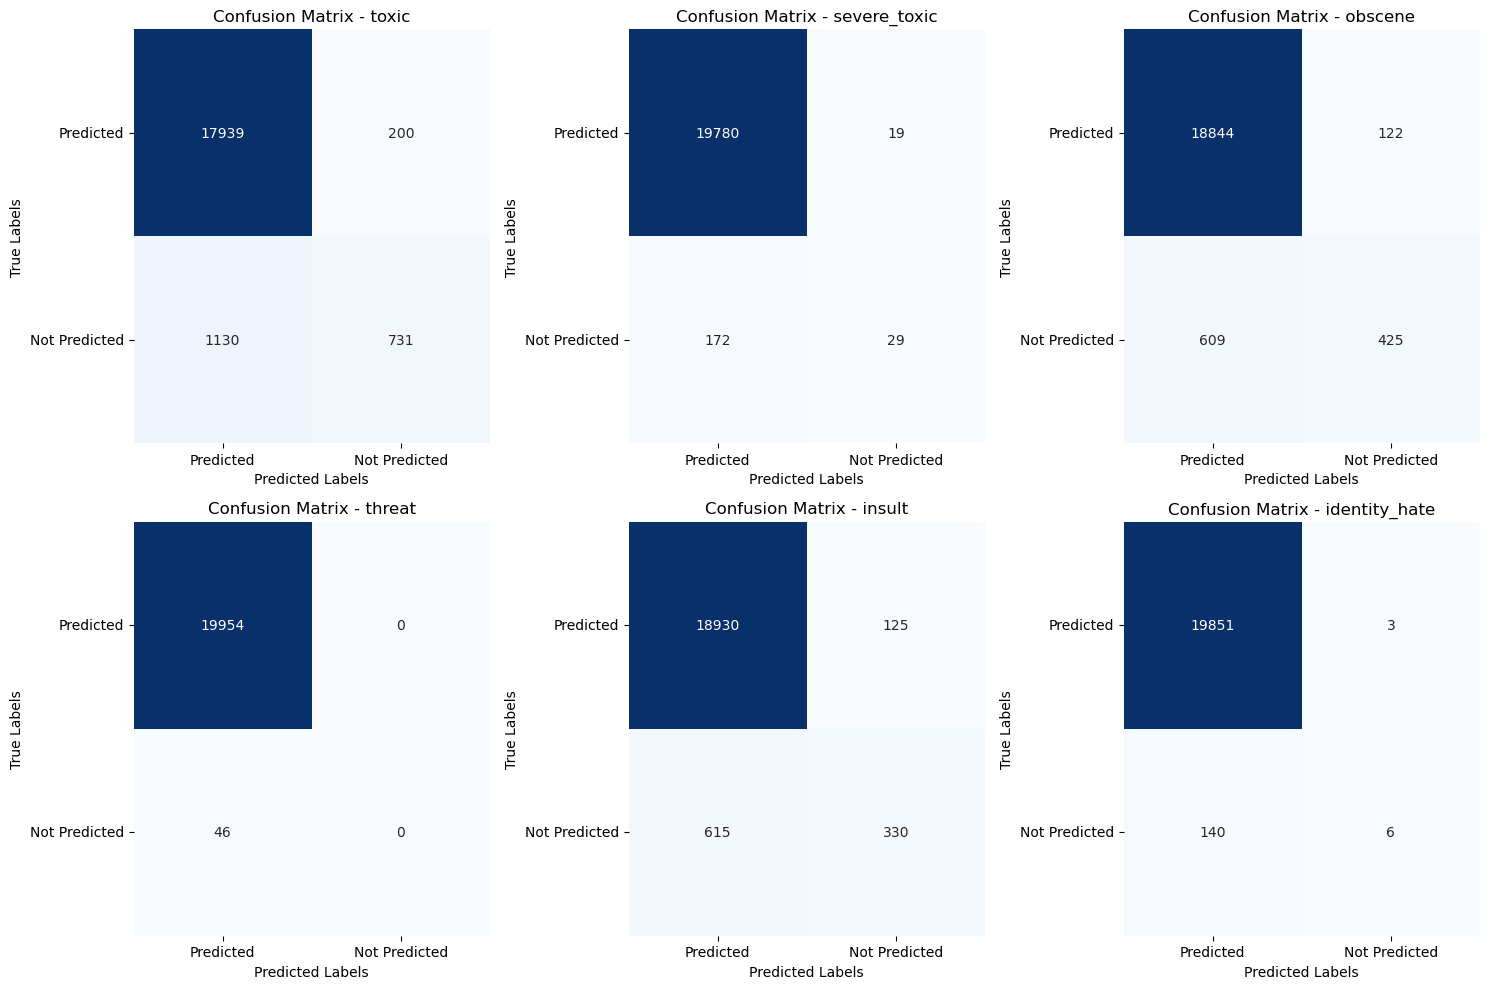

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns

# Define class names
class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

y_pred_binary = (y_pred_logreg > 0.5).astype(int)

# Compute the confusion matrix for each label
cm = multilabel_confusion_matrix(y_test_sample, y_pred_binary)

# Plot confusion matrices for each label
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flatten()):
    sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted', 'Not Predicted'], yticklabels=['Predicted', 'Not Predicted'],
                ax=ax)
    ax.set_title(f'Confusion Matrix - {class_names[i]}')
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
    ax.xaxis.set_tick_params(rotation=0)
    ax.yaxis.set_tick_params(rotation=0)
plt.tight_layout()
plt.show()

# XGBoost

In [23]:
#xgb
import xgboost as xgb 

#Sampling
# Define a smaller sample size
sample_size = 20000  # Adjust as needed

# Create a subset of the data
xg_train_sample = xg_train[:sample_size]
y_train_sample = y_train[:sample_size]
xg_test_sample = xg_test[:sample_size]
y_test_sample = y_test[:sample_size]


xgbmodel = OneVsRestClassifier(xgb.XGBClassifier(max_depth=4, n_estimators=100,learning_rate=0.1))
xgbmodel.fit(xg_train_sample, y_train_sample)
y_pred_xg = xgbmodel.predict_proba((xg_test_sample))

# Test Accuracy

In [24]:
# Calculate accuracy on the full test data
accuracy = accuracy_score(y_test_sample, (y_pred_xg > 0.5))
print("Test Accuracy: %.2f%%" % (accuracy * 100))

Test Accuracy: 90.53%


# F1 score

In [25]:
from sklearn.metrics import f1_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import MultiLabelBinarizer

y_test_sample = y_test_sample.values

# Binarize y_pred
threshold = 0.5
y_pred_binarized = (y_pred_xg > threshold).astype(int)

# Flatten the arrays
y_test_flat = y_test_sample.flatten()
y_pred_flat = y_pred_binarized.flatten()

# Calculate F1-score
f1 = f1_score(y_test_flat, y_pred_flat, average='macro')

print("F1-score:", f1)

F1-score: 0.7592826106997306


# Probability callibration curve

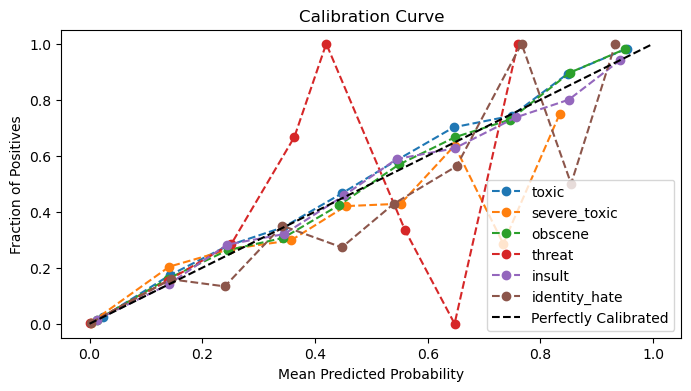

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
from sklearn.utils.multiclass import unique_labels

def plot_calibration_curve(y_test_sample, y_pred_xg, class_names=None, n_bins=10, strategy='uniform'):
    # Get unique classes from y_test_sample
    classes = unique_labels(y_test_sample)
    
    # Binarize the labels
    y_test_bin = label_binarize(y_test_sample, classes=classes)
    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(8, 4))

    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], y_pred_xg[:, i], n_bins=n_bins, strategy=strategy)
        label = f'Class {classes[i]}' if class_names is None else class_names[i]
        plt.plot(prob_pred, prob_true, marker='o', label=label, linestyle='--')

    plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title('Calibration Curve')
    plt.legend(loc='lower right')
    plt.show()

# Class names corresponding to the classes in y_test_sample
class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Specify the number of bins
n_bins = 10

plot_calibration_curve(y_test_sample, y_pred_xg, class_names=class_names, n_bins=n_bins)


# Confusion Matrix

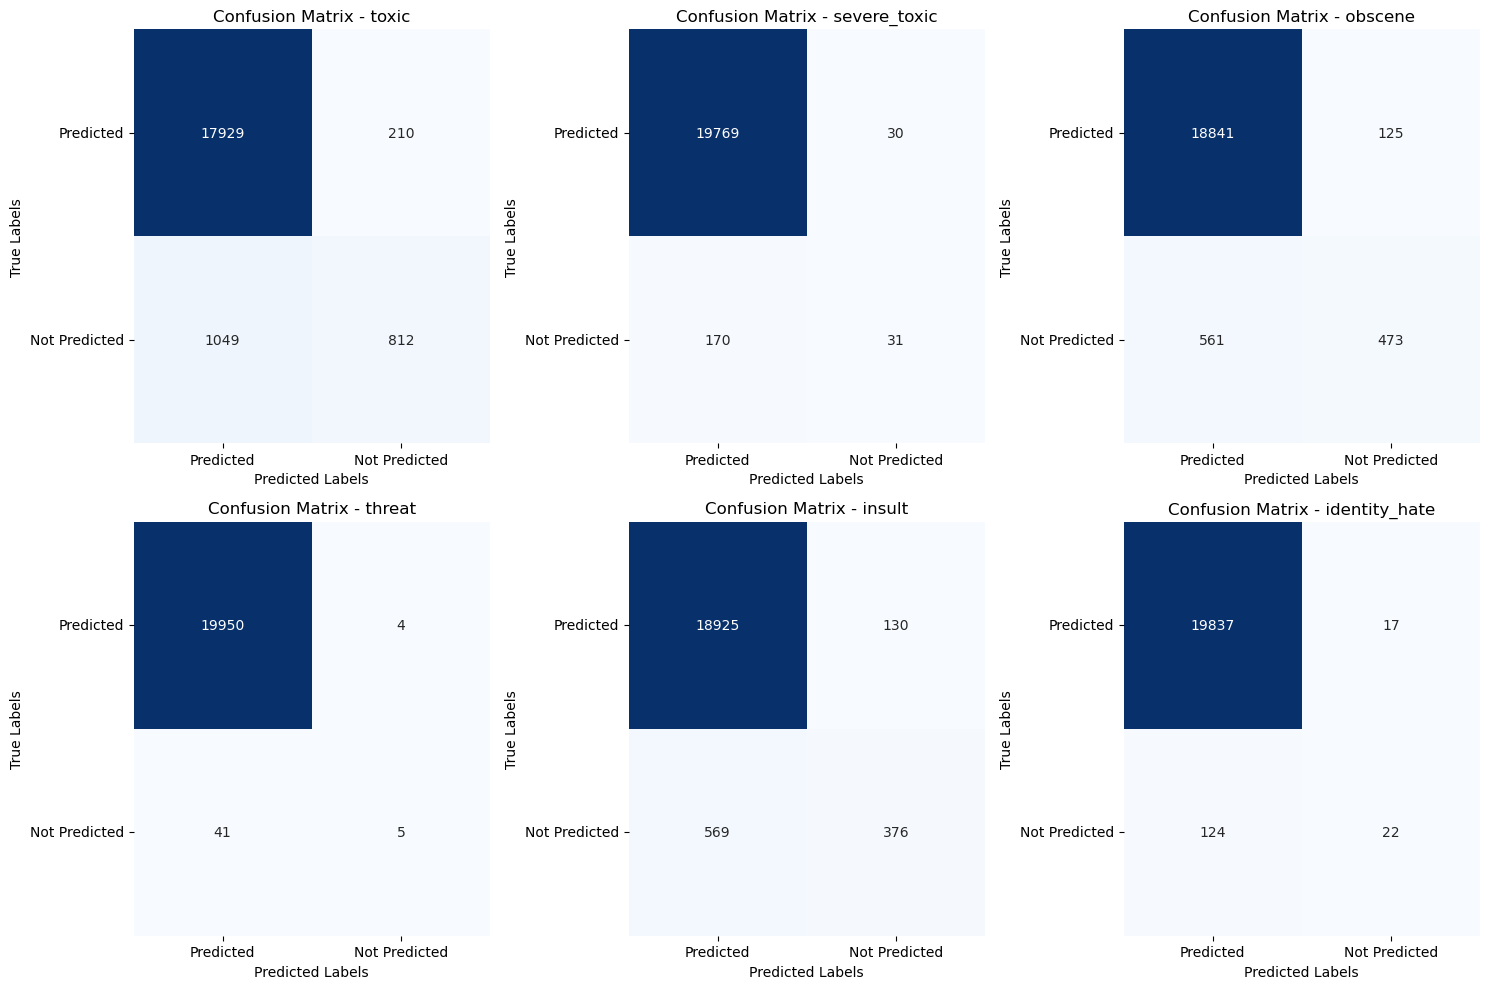

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns

# Define class names
class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

y_pred_binary = (y_pred_xg > 0.5).astype(int)

# Compute the confusion matrix for each label
cm = multilabel_confusion_matrix(y_test_sample, y_pred_binary)

# Plot confusion matrices for each label
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flatten()):
    sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted', 'Not Predicted'], yticklabels=['Predicted', 'Not Predicted'],
                ax=ax)
    ax.set_title(f'Confusion Matrix - {class_names[i]}')
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
    ax.xaxis.set_tick_params(rotation=0)
    ax.yaxis.set_tick_params(rotation=0)
plt.tight_layout()
plt.show()
